In [ ]:
import torch 
import torch.nn as nn
import numpy as np
from torch.nn import Parameter
import torch.nn.functional as F
import torch.optim as optim
from sklearn import metrics
import os
from tqdm import tqdm


from torch_geometric.utils import to_undirected, subgraph
from torch_geometric.data import Data, Batch, DataLoader

from config import config_train, config_test
from data_process import data_process_all_chrom, data_process

import models
from sampler import *
from aggregator import MaxminMeanAggregator

import utils
from batch import load_val

In [3]:
def model_eval(data, test_batchloader, model, Aggregator):
    model.eval()
    Aggregator.eval()
    with torch.no_grad():
        total_pred = []
        test_label = []
        num_data = 0

        v = model(data.x, data.edge_index, data.edge_attr)
        
        
        h_edges = []
        
        while True :
            hedges, labels, is_last = test_batchloader.next()
            batch_size = len(hedges)
            num_data+=batch_size
            for hedge in hedges:
                embeddings = v[hedge]
                #pred, _ = Aggregator(embeddings)
                max_min_dist = torch.max(hedge) - torch.min(hedge)
                pred, _ = Aggregator(max_min_dist,embeddings)
                total_pred.append(pred.detach())
                h_edges.append(hedge.cpu().numpy().tolist())
                
            test_label.append(labels.detach())
            
            
            if is_last :
                break
        total_pred = torch.stack(total_pred)       
        total_pred = total_pred.squeeze()
        test_label = torch.cat(test_label, dim=0)
        

    return total_pred.tolist(), test_label.tolist(), h_edges

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [5]:
dim_edge = 400
dim_vertex = 400

alpha_e = 0
alpha_v = 0

input_dim = 15 #features_num

n_layers = 1

size = 1000
nv = size

memory_size = 0

lr = 0.00004

bs = 512

memory_size = 0
clip = 0.01
n_layers = 3


In [6]:
model_dir = 'models/GM12878/'

model = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model.to(device)

if model_dir:
    model.load_state_dict(torch.load(model_dir+"model_epoch_7"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator.to(device)

if model_dir:
    Aggregator.load_state_dict(torch.load(model_dir+"Aggregator_epoch_7"))

In [7]:
import pickle

In [8]:
result = {}

for chr_name in ["chr14", "chr22", "chrX"]:

    with open("chrom_data/GM12878/"+chr_name+"_sliding_data","rb") as f:
        sliding_data = pickle.load(f)
    
    
    m = {}
    
    for data in sliding_data:
        a = []
        for i in data.hyper_edge:
            a.append(frozenset(i))

        b = {}
        for i in a:
            if i in b.keys():
                b[i] = b[i] + 1
            else:
                b[i] = 1

        
        data = data.to(device)
        test_batchloader = load_val(data.hyper_edge, bs, device, label="pos")
        val_pred_pos, total_label_pos, h_edges = model_eval(data, test_batchloader, model, Aggregator)
        


        for h,p in zip(h_edges, val_pred_pos):
    
            if b[frozenset(h)] in m.keys():
                m[b[frozenset(h)]].append(p)
        
            else:
                m[b[frozenset(h)]] = [p]
    
    
    result[chr_name] = m


In [ ]:
model_dir = 'models/K562/'

model = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model.to(device)

if model_dir:
    model.load_state_dict(torch.load(model_dir+"model_epoch_9"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator.to(device)

if model_dir:
    Aggregator.load_state_dict(torch.load(model_dir+"Aggregator_epoch_9"))

In [ ]:
result = {}

for chr_name in ["chr14", "chr22", "chrX"]:

    with open("chrom_data/K562/"+chr_name+"_sliding_data","rb") as f:
        sliding_data = pickle.load(f)
    
    
    m = {}
    
    for data in sliding_data:
        a = []
        for i in data.hyper_edge:
            a.append(frozenset(i))

        b = {}
        for i in a:
            if i in b.keys():
                b[i] = b[i] + 1
            else:
                b[i] = 1

        
        data = data.to(device)
        test_batchloader = load_val(data.hyper_edge, bs, device, label="pos")
        val_pred_pos, total_label_pos, h_edges = model_eval(data, test_batchloader, model, Aggregator)
        

        for h,p in zip(h_edges, val_pred_pos):
    
            if b[frozenset(h)] in m.keys():
                m[b[frozenset(h)]].append(p)
        
            else:
                m[b[frozenset(h)]] = [p]
    
    
    result[chr_name] = m


In [ ]:
#running both K562 and GM12878
# K562_order_freq = results

# with open("K562_order_freq","wb") as f:
#     pickle.dump(K562_order_freq, f)

In [ ]:
# GM12878_order_freq = results

# with open("GM12878_order_freq","wb") as f:
#     pickle.dump(GM12878_order_freq, f)

In [1]:
import pickle
with open("GM12878_order_freq","rb") as f:
    GM12878_order_freq = pickle.load(f)

In [4]:
with open("K562_order_freq","rb") as f:
    K562_order_freq = pickle.load(f)

In [ ]:
b = []

for i in range(1,7):
    
    a = []
    for v in GM12878_order_freq.values():
        if i in v.keys():
            a.extend(v[i])
        
    b.append(a)


In [3]:
g = b

In [5]:
b = []

for i in range(1,7):
    
    a = []
    for v in K562_order_freq.values():
        if i in v.keys():
            a.extend(v[i])
        
    b.append(a)


In [6]:
k = b

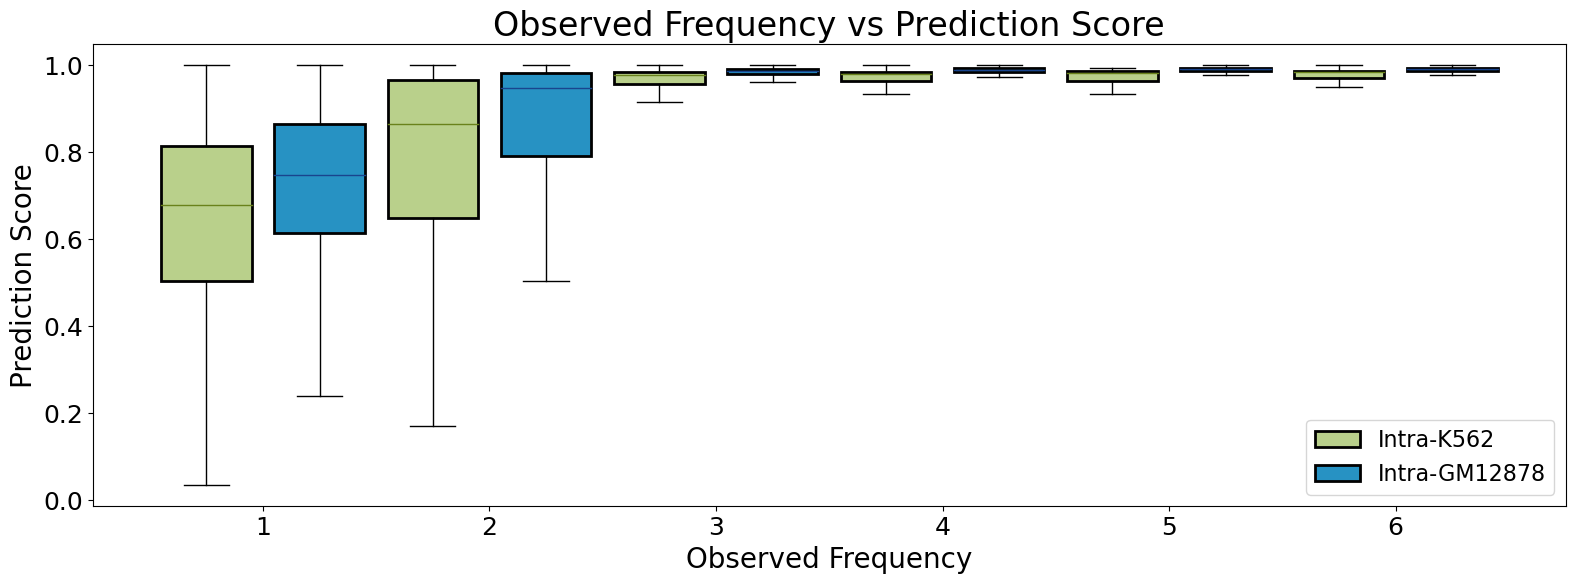

In [9]:
import matplotlib.pyplot as plt

# 设置字体
plt.rcParams.update({'font.size': 18})
# 假设 data_a 和 data_b 是两个同等长度的 list of list
data_a = k
data_b = g

# 设置箱型图的位置，假设有3组数据
positions = [1, 2, 3, 4, 5, 6]

# 画箱型图
fig, ax = plt.subplots(figsize=(19, 6))
boxprops_a = dict(facecolor="#b9d08b", linewidth=2)
boxprops_b = dict(facecolor="#2792c3", linewidth=2)

bp_a = ax.boxplot(data_a, positions=[pos - 0.25 for pos in positions],showfliers=False, widths=0.4, patch_artist=True, boxprops=boxprops_a, medianprops=dict(color='#69821b'))
bp_b = ax.boxplot(data_b, positions=[pos + 0.25 for pos in positions],showfliers=False, widths=0.4, patch_artist=True, boxprops=boxprops_b, medianprops=dict(color='#19448e'))

# 设置 x 轴标签
ax.set_xticks(positions)
ax.set_xticklabels(['1', '2', '3', '4', '5', '6'])

# 设置图表标题和轴标签
ax.set_title('Observed Frequency vs Prediction Score', fontsize=24)
ax.set_xlabel('Observed Frequency', fontsize=20)
ax.set_ylabel('Prediction Score', fontsize=20)

# 设置图例
ax.legend([bp_a["boxes"][0], bp_b["boxes"][0]], ['Intra-K562', 'Intra-GM12878'], fontsize=16, loc='lower right')

# 保存图表
plt.savefig('boxplot_figure.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()
